# Setup

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Preprocessing

In [2]:
df = pd.read_excel('../../../data/raw/covid.xlsx', engine="calamine")
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
df = df.map(lambda x: x.replace(' ', '_') if isinstance(x, str) else x)
df = df.map(lambda x: x.lower() if isinstance(x, str) else x)
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
df = df.drop(["№_истории_болезни", "фио"], axis=1)


df = df.rename({"волна": "wave"}, axis=1)
df["wave"] = df["wave"].astype("Int32")

df = df.rename({"койко-дней": "bed_day"}, axis=1)
df["bed_day"] = df["bed_day"].astype("float32")

df = df.rename({"исход": "clinical_outcome"}, axis=1)
df["clinical_outcome"] = df["clinical_outcome"].astype("boolean")


df = df.rename({"пол": "is_female"}, axis=1)
df["is_female"] = df["is_female"].map({1: False, 2: True})
df["is_female"] = df["is_female"].astype("boolean")

df = df.rename({"диагноз_заключительный": "is_lab_confirmed_covid"}, axis=1)
df["is_lab_confirmed_covid"] = df["is_lab_confirmed_covid"].map({"u07.2": False, "u07.1": True})
df["is_lab_confirmed_covid"] = df["is_lab_confirmed_covid"].astype("boolean")

# df['is_severe_disease_severity_поступление'] = df['тяжесть_состояния'] == 'тяжелое'
# df['is_severe_disease_severity_поступление'] = df['is_severe_disease_severity_поступление'].astype("boolean")
# df['is_moderate_disease_severity_поступление'] = df['тяжесть_состояния'] == 'средней_степени_тяжести'
# df['is_moderate_disease_severity_поступление'] = df['is_moderate_disease_severity_поступление'].astype("boolean")

# потом onehotencode
col = "тяжесть_состояния"
s = df[col].astype("string").str.strip().str.lower()
df[col] = np.select(
    [
        s.eq("тяжелое"),
        s.eq("средней_степени_тяжести"),
    ],
    [
        1,  # тяжелое
        0,  # средняя степень
    ],
    default=np.nan
).astype("float")
df = df.drop(["состояние"], axis=1)


def parse_spo2(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    # диапазон типа "94-95"
    if "-" in s:
        a, b = s.split("-", 1)
        try:
            return (float(a) + float(b)) / 2
        except:
            return np.nan
    # обычное число
    try:
        return float(s)
    except:
        return np.nan

df["spo2_5_день"] = df["spo2_5_день"].apply(parse_spo2)
# TODO Need to change negative data
df = df.rename({"госпитализирован_на_какие_сутки": "hospital_day"}, axis=1)
df["hospital_day"] = df["hospital_day"].astype("float32")


print("Размер", df.shape)
print("Int32", df.select_dtypes(include="Int32").columns.tolist())
print("float32", df.select_dtypes(include="float32").columns.tolist())
print("boolean", df.select_dtypes(include="boolean").columns.tolist())
print("datetime64[ns]", df.select_dtypes(include="datetime64[ns]").columns.tolist())
print(df.dtypes)
df.to_csv("liver.csv", index=False)
df.head(10)

Размер (404, 211)
Int32 ['wave']
float32 ['bed_day', 'hospital_day']
boolean ['clinical_outcome', 'is_female', 'is_lab_confirmed_covid']
datetime64[ns] ['дата_поступления', 'дата_выписки_(смерти)', 'дата_рождения', 'дата_заболевания', 'пцр-3_дата']
wave                                                                      Int32
дата_поступления                                                 datetime64[ns]
дата_выписки_(смерти)                                            datetime64[ns]
bed_day                                                                 float32
clinical_outcome                                                        boolean
дата_рождения                                                    datetime64[ns]
возраст                                                                   int64
возрастная_группа                                                         int64
2возрастные_группы                                                        int64
is_female                      

,wave,дата_поступления,дата_выписки_(смерти),bed_day,clinical_outcome,дата_рождения,возраст,возрастная_группа,2возрастные_группы,is_female,национальность,is_lab_confirmed_covid,тяжесть_состояния,дата_заболевания,hospital_day,место_контакта,вакцинация,вакцина,дата_вакцинации,дата_ревакцинации,пцр-1_дата,пцр-1_результат,пцр-2_дата,пцр-2_результат,пцр-3_дата,пцр-3_результат,табакокурение,t_тела,аносмия,общая_слабость,кашель,одышка,чувство_сдвления_в_груди,гол.боль,диарея,тошнота,тахикардия,наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза,сепсис,коморбидность,сд_2_типа,гипотиреоз,диффузный_(эндемический)_зоб,заб_ссс,аг,ибс,нрс_(нарушение_ритма_сердца),заболевания_печени,хронический_гепатит,заболевания_легких,бронхиальная_астма,хронический_бронхит,онкологические_заболевания,заболевание_почек_(хбп),имт_(рост_и_вес),категории_имт,имт_и_ожирение,поступление,лейкоциты_поступление,кат_лейкоциты_поступление,лимфоциты_поступление,кат_лимфоциты_поступление,палочкрядерные_поступление,кат_палочкрядерные_поступление,эритроциты_поступление,кат_эритроциты_поступление,гемоглобин_поступление,кат_гемоглобин_поступление,соэ_поступление,кат_соэ_поступление,spo2_поступление,кат_spo2_поступление,с-реактивный_белок_поступление,кат_с-реактивный_белок_поступление,алт_поступление,кат_алт_поступление,аст_поступление,кат_аст_поступление,глюкоза_поступление,кат_глюкоза_поступление,лдг_поступление,кат_лдг_поступление,креатинин_поступление,кат_креатинин_поступление,мочевина_поступление,кат_мочевина_поступление,пти_поступление,кат_пти_поступление,мно_поступление,кат_мно_поступление,протромбиновое_время__поступление,кат_протромбиновое_время__поступление,тромбоциты_при_поступлении,кат_тромбоциты_при_поступлении,д-димер_поступление,кат_д-димер_поступление,ил-6_поступление,кат_ил-6_поступление,ферритин_поступление,кат_ферритин_поступление,ифа_на_covid-19,igm,igg,противовирусная_терапия,"кт,_rh_1","кт,_rh_2","кт,_rh_3","кт,_rh_4",кт_при_поступлении,кт_в_динамике,цифровая_оценка_динамики,динамика_кт,оценка_динамики,5_день,лейкоциты_5_день,кат_лейкоциты_5_день,лимфоциты_5_день,кат_лимфоциты_5_день,палочкоядерные_5_день,кат_палочкоядерные_5_день,эритроциты_5_день,кат_эритроциты_5_день,гемоглобин_5_день,кат_гемоглобин_5_день,соэ_5_день,кат_соэ_5_день,spo2_5_день,кат_spo2_5_день,с-реактивый_белок_5_день,кат_с-реактивый_белок_5_день,алт_5_день,кат_алт_5_день,аст_5_день,кат_аст_5_день,глюкоза_5_день,кат_глюкоза_5_день,лдг_5_день,кат_лдг_5_день,креатинин_5_день,кат_креатинин_5_день,мочевина_5_день,кат_мочевина_5_день,пти_5_день,кат_пти_5_день,мно_5_день,кат_мно_5_день,тромбоциты_5-й_день,кат_тромбоциты_5-й_день,д-димер_5_день,кат_д-димер_5_день,выписка,лейкоциты_выписка,кат_лейкоциты_выписка,лимфоциты__выписка,кат_лимфоциты__выписка,палочкоядерные__выписка,кат_палочкоядерные__выписка,эритроциты__выписка,кат_эритроциты__выписка,гемоглобин__выписка,кат_гемоглобин__выписка,соэ__выписка,кат_соэ__выписка,spo2__выписка,кат_spo2__выписка,с-реактивый_белок__выписка,кат_с-реактивый_белок__выписка,алт__выписка,кат_алт__выписка,аст__выписка,кат_аст__выписка,глюкоза__выписка,кат_глюкоза__выписка,лдг__выписка,кат_лдг__выписка,креатинин__выписка,кат_креатинин__выписка,мочевина__выписка,кат_мочевина__выписка,пти__выписка,кат_пти__выписка,мно__выписка,кат_мно__выписка,тромбоциты_при_выписке/смерти,кат_тромбоциты_при_выписке/смерти,д-димер__выписка,кат_д-димер__выписка,шкала_по_apache_ii_при_поступлении_в_оарит,шкала_по_sofa_при_поступлении_в_оарит,шкала_комы_глазго_при_поступлении_в_оарит,шкала_по_apache_ii_в_динамике,шкала_по_sofa_в_динамике,шкала_комы_глазго_в_динамике,шкала_по_apache_ii_при_смерти,шкала_по_sofa_при_смерти,шкала_комы_глазго_при_смерти,"кт,_rh",ркт_огк_в_динамике,оценка_кт,динамика_кт_1_отриц,кт_при_поступлении.1,unnamed:_204,наличие_дыхательной_недостаточностью,дн_0,дн_0-1,дн_1,дн_1-2,дн_2-3,дн_3,дн_любой_степени,"кт,_rh.1"
0,2,2021-06-04,2021-06-21,17.0,True,1936-04-04,85,4,2,True,1,True,1.0,2021-06-03,1.0,0,0.0,NaN,NaN,NaN,2021-06-04 00:00:00,1,2021-06-20 

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Columns: 211 entries, wave to кт,_rh.1
dtypes: Int32(1), boolean(3), datetime64[ns](5), float32(2), float64(119), int64(60), object(21)
memory usage: 654.7+ KB


In [180]:
#флоатизирование температуры тела
s = df["t_тела"] 

s = s.astype("string").str.strip()
mask_no = s.str.fullmatch(r"(?i)нет")
s = s.mask(mask_no)

num = s.str.extract(r"(\d+(?:[.,]\d+)?)", expand=False)

df["t_тела"] = pd.to_numeric(num.str.replace(",", ".", regex=False), errors="coerce")

dummies = pd.get_dummies(df["противовирусная_терапия"], prefix="противовирусная_терапия", dtype="int8")  # или dtype=int
df = df.drop(columns=["противовирусная_терапия"]).join(dummies)

In [181]:
# в падлу делать, подумай igm, igg много значений мб зароляет
df['is_lab_confirmed_covid'].value_counts() # 3 false все остальное тру

df = df.drop(columns = ['is_lab_confirmed_covid', 'igm', 'igg'])


In [182]:
df.to_csv("covid.csv", index=False, encoding="utf-8")

# Essentials

## Обзор

In [18]:
df = pd.read_csv('../../../project/maxim/covid/covid.csv')
df = df.drop(columns=
             ["дата_поступления", "дата_выписки_(смерти)", "дата_рождения", 
              "дата_заболевания", "пцр-1_дата", "пцр-2_дата", "пцр-3_дата", "дата_вакцинации", "дата_ревакцинации",
              "ифа_на_covid-19", "возрастная_группа", "2возрастные_группы", "пцр-1_результат", "пцр-2_результат","пцр-3_результат",
              "категории_имт", "поступление",
                "кт,_rh_1", "кт,_rh_2", "кт,_rh_3", "кт,_rh_4",
                "оценка_динамики", "5_день", "выписка", "цифровая_оценка_динамики", "динамика_кт",
                "кт,_rh", "ркт_огк_в_динамике",
                		"оценка_кт",	"динамика_кт_1_отриц"	, "кт_при_поступлении.1",
                "unnamed:_204", "наличие_дыхательной_недостаточностью", "дн_0",	"дн_0-1", "дн_1", "дн_1-2",
                    	"дн_2-3", "дн_3", "дн_любой_степени", "кт,_rh.1"
                
              ])
df = df.rename(columns={"clinical_outcome": "смерть", "тромбоциты_при_поступлении" : "тромбоциты_при_поступление", 
                        "кат_тромбоциты_при_поступлении" : "кат_тромбоциты_при_поступление",
                        "кт_при_поступлении": "кт_при_поступление",
                        "кт_в_динамике": "кт_в_динамике_5_день",
                        "тромбоциты_5-й_день" : "тромбоциты_5_день",
                        "кат_тромбоциты_5-й_день" : "кат_тромбоциты_5_день",
                        "тромбоциты_при_выписке/смерти" : "тромбоциты_при_выписка",
                        "кат_тромбоциты_при_выписке/смерти" : "кат_тромбоциты_при_выписка"})
df.head(5) 
df.head(5) 

,wave,bed_day,смерть,возраст,is_female,национальность,тяжесть_состояния,hospital_day,место_контакта,вакцинация,вакцина,табакокурение,t_тела,аносмия,общая_слабость,кашель,одышка,чувство_сдвления_в_груди,гол.боль,диарея,тошнота,тахикардия,наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза,сепсис,коморбидность,сд_2_типа,гипотиреоз,диффузный_(эндемический)_зоб,заб_ссс,аг,ибс,нрс_(нарушение_ритма_сердца),заболевания_печени,хронический_гепатит,заболевания_легких,бронхиальная_астма,хронический_бронхит,онкологические_заболевания,заболевание_почек_(хбп),имт_(рост_и_вес),имт_и_ожирение,лейкоциты_поступление,кат_лейкоциты_поступление,лимфоциты_поступление,кат_лимфоциты_поступление,палочкрядерные_поступление,кат_палочкрядерные_поступление,эритроциты_поступление,кат_эритроциты_поступление,гемоглобин_поступление,кат_гемоглобин_поступление,соэ_поступление,кат_соэ_поступление,spo2_поступление,кат_spo2_поступление,с-реактивный_белок_поступление,кат_с-реактивный_белок_поступление,алт_поступление,кат_алт_поступление,аст_поступление,кат_аст_поступление,глюкоза_поступление,кат_глюкоза_поступление,лдг_поступление,кат_лдг_поступление,креатинин_поступление,кат_креатинин_поступление,мочевина_поступление,кат_мочевина_поступление,пти_поступление,кат_пти_поступление,мно_поступление,кат_мно_поступление,протромбиновое_время__поступление,кат_протромбиновое_время__поступление,тромбоциты_при_поступление,кат_тромбоциты_при_поступление,д-димер_поступление,кат_д-димер_поступление,ил-6_поступление,кат_ил-6_поступление,ферритин_поступление,кат_ферритин_поступление,кт_при_поступление,кт_в_динамике_5_день,лейкоциты_5_день,кат_лейкоциты_5_день,лимфоциты_5_день,кат_лимфоциты_5_день,палочкоядерные_5_день,кат_палочкоядерные_5_день,эритроциты_5_день,кат_эритроциты_5_день,гемоглобин_5_день,кат_гемоглобин_5_день,соэ_5_день,кат_соэ_5_день,spo2_5_день,кат_spo2_5_день,с-реактивый_белок_5_день,кат_с-реактивый_белок_5_день,алт_5_день,кат_алт_5_день,аст_5_день,кат_аст_5_день,глюкоза_5_день,кат_глюкоза_5_день,лдг_5_день,кат_лдг_5_день,креатинин_5_день,кат_креатинин_5_день,мочевина_5_день,кат_мочевина_5_день,пти_5_день,кат_пти_5_день,мно_5_день,кат_мно_5_день,тромбоциты_5_день,кат_тромбоциты_5_день,д-димер_5_день,кат_д-димер_5_день,лейкоциты_выписка,кат_лейкоциты_выписка,лимфоциты__выписка,кат_лимфоциты__выписка,палочкоядерные__выписка,кат_палочкоядерные__выписка,эритроциты__выписка,кат_эритроциты__выписка,гемоглобин__выписка,кат_гемоглобин__выписка,соэ__выписка,кат_соэ__выписка,spo2__выписка,кат_spo2__выписка,с-реактивый_белок__выписка,кат_с-реактивый_белок__выписка,алт__выписка,кат_алт__выписка,аст__выписка,кат_аст__выписка,глюкоза__выписка,кат_глюкоза__выписка,лдг__выписка,кат_лдг__выписка,креатинин__выписка,кат_креатинин__выписка,мочевина__выписка,кат_мочевина__выписка,пти__выписка,кат_пти__выписка,мно__выписка,кат_мно__выписка,тромбоциты_при_выписка,кат_тромбоциты_при_выписка,д-димер__выписка,кат_д-димер__выписка,шкала_по_apache_ii_при_поступлении_в_оарит,шкала_по_sofa_при_поступлении_в_оарит,шкала_комы_глазго_при_поступлении_в_оарит,шкала_по_apache_ii_в_динамике,шкала_по_sofa_в_динамике,шкала_комы_глазго_в_динамике,шкала_по_apache_ii_при_смерти,шкала_по_sofa_при_смерти,шкала_комы_глазго_при_смерти,противовирусная_терапия_арбидол,противовирусная_терапия_гидроксихлорохин_по_схеме,противовирусная_терапия_гриппферон,противовирусная_терапия_калетра_по_схеме,противовирусная_терапия_фавипиравир
0,2,17.0,True,85,True,1,1.0,1.0,0,0.0,NaN,0,37.8,0,1,1,1,1,0,0,0,1,1,0,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0.0,23.7,0,8.19,2,0.58,1,4,2,4.37,2,122.0,2,14,2,94,1,88.3,3,164.0,3,97.8,3,8.50,3,412.0,3,90.0,2,8.2,3,90.0,1,1.10,2,12.6,2,203.0,2,111.0,2,14.0,3,800.0,3,3,4,21.67,3.0,1.34,2.0,4.0,2.0,4.69,2.0,131.0,2.0,4.0,2.0,85.0,1.0,1.8,2.0,61.7,3.0,31.8,2.0,12.84,3.0,452.0,3.0,89.0,2.0,10.1,3.0,89.0,1.0,1.01,2.0,323.0,3.0,380.0,3.0,45.69,3.0,3.75,2.0,10.0,3.0,4.38,2.0,125.0,2.0,1.0,1.0,77.0,1.0,0.8,2.0,29.7,2.0,34.6,3.0,8.60,3.0,514.0,3.0,236.0,3.0,35.9,3.0,59.0,1.0,1.44,3.0,91,1.0,441.0,3.0,

## micro preprocessing

In [19]:
import re

general_cols = [
    "wave", "bed_day", "возраст", 
    "is_female", "национальность", "hospital_day",
    "место_контакта", "вакцинация", "вакцина", "табакокурение", "t_тела", "аносмия",
    "общая_слабость", "кашель", "одышка", "чувство_сдвления_в_груди", "гол.боль",
    "диарея", "тошнота", "тахикардия", "наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза",
    "сепсис", "коморбидность", "сд_2_типа", "гипотиреоз", "диффузный_(эндемический)_зоб",
    "заб_ссс", "аг", "ибс", "нрс_(нарушение_ритма_сердца)",
    "заболевания_печени","хронический_гепатит","заболевания_легких","бронхиальная_астма","хронический_бронхит",
    "онкологические_заболевания","заболевание_почек_(хбп)","имт_(рост_и_вес)","имт_и_ожирение",
    "противовирусная_терапия_арбидол", "противовирусная_терапия_гидроксихлорохин_по_схеме"	,
    "противовирусная_терапия_гриппферон", "противовирусная_терапия_калетра_по_схеме", "противовирусная_терапия_фавипиравир"	

    # добавь сюда при желании любые "постоянные" признаки
]
target_cols = [
    "смерть", "тяжесть_состояния"
]

death_cols = [
    "шкала_по_apache_ii_при_поступлении_в_оарит",
    "шкала_по_sofa_при_поступлении_в_оарит",
    "шкала_комы_глазго_при_поступлении_в_оарит",
    "шкала_по_apache_ii_в_динамике",
    "шкала_по_sofa_в_динамике",
    "шкала_комы_глазго_в_динамике",
    "шкала_по_apache_ii_при_смерти",
    "шкала_по_sofa_при_смерти",
    "шкала_комы_глазго_при_смерти"

]
# suffixes = ("_поступление", "_5_день", "_выписка")

# # 1) все "общие" колонки = не относящиеся к временным срезам
# general_cols = [c for c in df.columns if not c.endswith(suffixes)]
def slice_by_suffix(df, suffix: str):
    time_cols = [c for c in df.columns if c.endswith(suffix)]
    out = df[general_cols + time_cols].copy()

    return out

df_d1 = slice_by_suffix(df, "_поступление")
df_d5  = slice_by_suffix(df, "_5_день")
df_d10 = slice_by_suffix(df, "_выписка")

In [8]:
df_d1.head(5)

,wave,bed_day,возраст,is_female,национальность,hospital_day,место_контакта,вакцинация,вакцина,табакокурение,t_тела,аносмия,общая_слабость,кашель,одышка,чувство_сдвления_в_груди,гол.боль,диарея,тошнота,тахикардия,наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза,сепсис,коморбидность,сд_2_типа,гипотиреоз,диффузный_(эндемический)_зоб,заб_ссс,аг,ибс,нрс_(нарушение_ритма_сердца),заболевания_печени,хронический_гепатит,заболевания_легких,бронхиальная_астма,хронический_бронхит,онкологические_заболевания,заболевание_почек_(хбп),имт_(рост_и_вес),имт_и_ожирение,противовирусная_терапия_арбидол,противовирусная_терапия_гидроксихлорохин_по_схеме,противовирусная_терапия_гриппферон,противовирусная_терапия_калетра_по_схеме,противовирусная_терапия_фавипиравир,лейкоциты_поступление,кат_лейкоциты_поступление,лимфоциты_поступление,кат_лимфоциты_поступление,палочкрядерные_поступление,кат_палочкрядерные_поступление,эритроциты_поступление,кат_эритроциты_поступление,гемоглобин_поступление,кат_гемоглобин_поступление,соэ_поступление,кат_соэ_поступление,spo2_поступление,кат_spo2_поступление,с-реактивный_белок_поступление,кат_с-реактивный_белок_поступление,алт_поступление,кат_алт_поступление,аст_поступление,кат_аст_поступление,глюкоза_поступление,кат_глюкоза_поступление,лдг_поступление,кат_лдг_поступление,креатинин_поступление,кат_креатинин_поступление,мочевина_поступление,кат_мочевина_поступление,пти_поступление,кат_пти_поступление,мно_поступление,кат_мно_поступление,протромбиновое_время__поступление,кат_протромбиновое_время__поступление,тромбоциты_при_поступление,кат_тромбоциты_при_поступление,д-димер_поступление,кат_д-димер_поступление,ил-6_поступление,кат_ил-6_поступление,ферритин_поступление,кат_ферритин_поступление,кт_при_поступление
0,2,17.0,85,True,1,1.0,0,0.0,NaN,0,37.8,0,1,1,1,1,0,0,0,1,1,0,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0.0,23.7,0,0,0,0,0,1,8.19,2,0.58,1,4,2,4.37,2,122.0,2,14,2,94,1,88.3,3,164.0,3,97.8,3,8.50,3,412.0,3,90.0,2,8.2,3,90.0,1,1.10,2,12.6,2,203.0,2,111.0,2,14.0,3,800.0,3,3
1,2,8.0,85,True,1,0.0,0,0.0,NaN,0,37.5,0,1,1,1,1,0,0,0,1,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1.0,20.1,0,0,0,0,0,1,5.45,2,0.49,1,5,2,4.57,2,122.0,2,54,3,87,1,116.9,3,12.2,2,25.9,2,5.51,2,189.0,2,136.0,3,22.5,3,100.0,2,1.04,2,14.5,2,478.0,3,256.0,3,55.0,3,1508.0,3,2
2,2,7.0,75,True,1,3.0,3,0.0,NaN,0,NaN,0,1,1,1,1,1,0,0,1,1,0,1,0,0,0,1,1,1,0,0,0,0,0,1,0,0.0,26.5,1,0,0,0,0,1,13.68,3,1.53,2,16,3,4.63,2,119.0,1,35,3,89,1,68.7,3,27.8,2,33.5,3,7.70,3,218.0,2,78.0,2,2.6,2,107.0,3,2.00,3,14.8,2,225.0,2,176.0,2,68.5,3,429.0,3,3
3,2,31.0,81,True,1,4.0,0,0.0,NaN,0,37.5,0,1,1,1,1,0,0,0,0,2,0,1,1,0,0,1,1,1,0,0,0,1,0,1,0,0.0,27.0,1,0,0,0,0,1,7.00,2,2.15,2,9,3,4.31,2,104.0,1,34,3,97,0,103.2,3,16.8,2,17.8,2,4.93,2,218.0,2,99.0,3,9.7,3,98.6,2,1.01,2,11.5,2,245.0,2,196.0,2,15.9,3,155.8,3,2
4,2,39.0,80,False,1,14.0,0,0.0,NaN,0,38.0,0,1,1,1,1,1,0,0,1,1,0,1,0,0,0,1,1,1,0,0,0,1,1,0,0,0.0,29.4,1,0,0,0,0,1,16.48,3,0.59,1,4,2,5.46,3,166.0,3,2,2,80,1,174.0,3,91.8,3,24.4,2,13.70,3,452.0,3,210.0,3,62.3,3,57.0,1,1.96,3,26.5,3,113.0,1,256.0,3,185.0,3,1003.0,3,4


In [6]:
df.columns

Index(['wave', 'bed_day', 'смерть', 'возраст', 'is_female', 'национальность',
       'тяжесть_состояния', 'hospital_day', 'место_контакта', 'вакцинация',
       ...
       'шкала_по_sofa_в_динамике', 'шкала_комы_глазго_в_динамике',
       'шкала_по_apache_ii_при_смерти', 'шкала_по_sofa_при_смерти',
       'шкала_комы_глазго_при_смерти', 'противовирусная_терапия_арбидол',
       'противовирусная_терапия_гидроксихлорохин_по_схеме',
       'противовирусная_терапия_гриппферон',
       'противовирусная_терапия_калетра_по_схеме',
       'противовирусная_терапия_фавипиравир'],
      dtype='object', length=171)

In [7]:
df[target_cols[1]].value_counts()

тяжесть_состояния
0.0    246
1.0    158
Name: count, dtype: int64

## Модель

## При поступлении кто и почему средние и тяжелые?

In [139]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

y = df[target_cols[1]]
X = df_d1

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(cat_cols)
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_cols)
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced"  # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))
imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

[]
0:	test: 0.7965561	best: 0.7965561 (0)	total: 118ms	remaining: 3m 56s
200:	test: 0.9438776	best: 0.9553571 (47)	total: 968ms	remaining: 8.66s
400:	test: 0.9400510	best: 0.9553571 (47)	total: 1.84s	remaining: 7.36s
600:	test: 0.9413265	best: 0.9553571 (47)	total: 2.74s	remaining: 6.39s
800:	test: 0.9413265	best: 0.9553571 (47)	total: 3.49s	remaining: 5.23s
1000:	test: 0.9406888	best: 0.9553571 (47)	total: 4.2s	remaining: 4.19s
1200:	test: 0.9406888	best: 0.9553571 (47)	total: 4.87s	remaining: 3.24s
1400:	test: 0.9406888	best: 0.9553571 (47)	total: 5.55s	remaining: 2.37s
1600:	test: 0.9394133	best: 0.9553571 (47)	total: 6.2s	remaining: 1.55s
1800:	test: 0.9381378	best: 0.9553571 (47)	total: 6.88s	remaining: 760ms
1999:	test: 0.9375000	best: 0.9553571 (47)	total: 7.55s	remaining: 0us

bestTest = 0.9553571429
bestIteration = 47

Shrink model to first 48 iterations.
ROC-AUC: 0.9553571428571428
              precision    recall  f1-score   support

         0.0       0.85      0.96      0

## Что влияет на исход смерти данные при поступлении

один фактор имеет слишком большую предсказательную силу
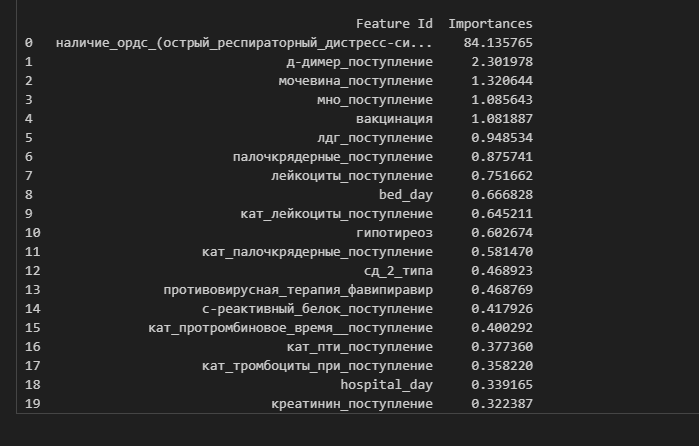

In [148]:
df_d1_withoutORDS = df_d1.copy()
df_d1_withoutORDS = df_d1_withoutORDS.drop(columns = "наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза")

In [149]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

y = df[target_cols[0]]
X = df_d1_withoutORDS

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(cat_cols)
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_cols)
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced"  # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))
imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

[]
0:	test: 0.9057971	best: 0.9057971 (0)	total: 5.49ms	remaining: 11s
200:	test: 0.9323671	best: 0.9492754 (17)	total: 851ms	remaining: 7.61s
400:	test: 0.9311594	best: 0.9492754 (17)	total: 1.61s	remaining: 6.41s
600:	test: 0.9323671	best: 0.9492754 (17)	total: 2.35s	remaining: 5.46s
800:	test: 0.9299517	best: 0.9492754 (17)	total: 3.07s	remaining: 4.6s
1000:	test: 0.9347826	best: 0.9492754 (17)	total: 3.76s	remaining: 3.76s
1200:	test: 0.9335749	best: 0.9492754 (17)	total: 4.42s	remaining: 2.94s
1400:	test: 0.9335749	best: 0.9492754 (17)	total: 5.06s	remaining: 2.17s
1600:	test: 0.9335749	best: 0.9492754 (17)	total: 5.72s	remaining: 1.43s
1800:	test: 0.9335749	best: 0.9492754 (17)	total: 6.37s	remaining: 704ms
1999:	test: 0.9335749	best: 0.9492754 (17)	total: 7.03s	remaining: 0us

bestTest = 0.9492753623
bestIteration = 17

Shrink model to first 18 iterations.
ROC-AUC: 0.9492753623188406
              precision    recall  f1-score   support

       False       0.96      0.99      0.

## Что влияет на исход смерти данные на 5 день

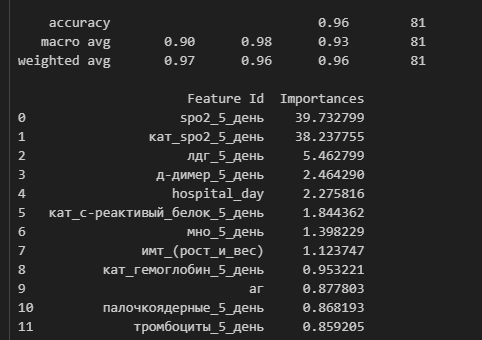
spo2 slishkom mnogo

In [245]:
df_d5_withoutORDS = df_d5.copy()
df_d5_withoutORDS = df_d5_withoutORDS.drop(columns = ["наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза","spo2_5_день",  "кат_spo2_5_день"])

In [246]:
df['spo2_5_день'].value_counts()

spo2_5_день
98.0    87
97.0    65
96.0    59
99.0    58
95.0    36
89.0    12
92.0    12
93.0    12
90.0    11
80.0     9
94.0     8
85.0     5
84.0     4
86.0     4
75.0     3
88.0     3
79.0     2
81.0     2
77.0     1
94.5     1
82.0     1
91.0     1
83.0     1
87.0     1
Name: count, dtype: int64

In [247]:
col = "кт_в_динамике_5_день"
df_d5_withoutORDS[col] = df_d5_withoutORDS[col].replace("не_сделан", np.nan)
df_d5_withoutORDS['кт_в_динамике_5_день'].value_counts()

кт_в_динамике_5_день
2    139
1    135
3     64
4     59
Name: count, dtype: int64

In [248]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

y = df[target_cols[0]]
X = df_d5_withoutORDS

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced"  # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))
imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

['кт_в_динамике_5_день']
0:	test: 0.9981884	best: 0.9981884 (0)	total: 3.86ms	remaining: 7.71s
200:	test: 1.0000000	best: 1.0000000 (1)	total: 579ms	remaining: 5.18s
400:	test: 1.0000000	best: 1.0000000 (1)	total: 1.11s	remaining: 4.44s
600:	test: 1.0000000	best: 1.0000000 (1)	total: 1.61s	remaining: 3.74s
800:	test: 1.0000000	best: 1.0000000 (1)	total: 2.06s	remaining: 3.09s
1000:	test: 1.0000000	best: 1.0000000 (1)	total: 2.51s	remaining: 2.5s
1200:	test: 1.0000000	best: 1.0000000 (1)	total: 3s	remaining: 2s
1400:	test: 1.0000000	best: 1.0000000 (1)	total: 3.51s	remaining: 1.5s
1600:	test: 1.0000000	best: 1.0000000 (1)	total: 4.01s	remaining: 1s
1800:	test: 1.0000000	best: 1.0000000 (1)	total: 4.5s	remaining: 497ms
1999:	test: 1.0000000	best: 1.0000000 (1)	total: 4.92s	remaining: 0us

bestTest = 1
bestIteration = 1

Shrink model to first 2 iterations.
ROC-AUC: 1.0
              precision    recall  f1-score   support

       False       1.00      0.97      0.99        69
        True

## Что влияет на исход смерти на день выпуска/смерти

spo2 слишком много
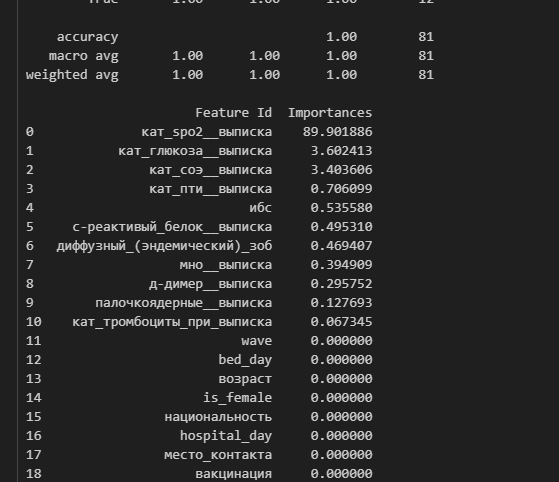

In [241]:
df_d10_withoutORDS = df_d10.copy()
df_d10_withoutORDS = df_d10_withoutORDS.drop(columns = ["наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза","spo2__выписка",  "кат_spo2__выписка"])

In [242]:
df_d10_withoutORDS['тромбоциты_при_выписка'].value_counts()
col = "тромбоциты_при_выписка"

df_d10_withoutORDS[col] = (
    df_d10_withoutORDS[col]
    .astype("string")
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df_d10_withoutORDS[col] = pd.to_numeric(df_d10_withoutORDS[col], errors="coerce")

In [243]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

y = df[target_cols[0]]
X = df_d10_withoutORDS

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced"  # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))
imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

[]
0:	test: 1.0000000	best: 1.0000000 (0)	total: 2.38ms	remaining: 4.76s
200:	test: 1.0000000	best: 1.0000000 (0)	total: 561ms	remaining: 5.02s
400:	test: 1.0000000	best: 1.0000000 (0)	total: 1.02s	remaining: 4.06s
600:	test: 1.0000000	best: 1.0000000 (0)	total: 1.46s	remaining: 3.41s
800:	test: 1.0000000	best: 1.0000000 (0)	total: 1.94s	remaining: 2.91s
1000:	test: 1.0000000	best: 1.0000000 (0)	total: 2.4s	remaining: 2.39s
1200:	test: 1.0000000	best: 1.0000000 (0)	total: 2.84s	remaining: 1.89s
1400:	test: 1.0000000	best: 1.0000000 (0)	total: 3.34s	remaining: 1.43s
1600:	test: 1.0000000	best: 1.0000000 (0)	total: 3.8s	remaining: 948ms
1800:	test: 1.0000000	best: 1.0000000 (0)	total: 4.24s	remaining: 468ms
1999:	test: 1.0000000	best: 1.0000000 (0)	total: 4.68s	remaining: 0us

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.
ROC-AUC: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        69
        True       1.00 

In [8]:
df['тяжесть_состояния']

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
5      1.0
6      0.0
7      1.0
8      1.0
9      1.0
10     0.0
11     0.0
12     1.0
13     1.0
14     1.0
15     1.0
16     0.0
17     0.0
18     1.0
19     1.0
20     1.0
21     1.0
22     1.0
23     1.0
24     1.0
25     1.0
26     1.0
27     1.0
28     1.0
29     1.0
30     1.0
31     1.0
32     1.0
33     0.0
34     0.0
35     1.0
36     1.0
37     1.0
38     0.0
39     1.0
40     1.0
41     0.0
42     0.0
43     1.0
44     0.0
45     1.0
46     1.0
47     1.0
48     1.0
49     1.0
50     1.0
51     0.0
52     0.0
53     0.0
54     0.0
55     0.0
56     0.0
57     0.0
58     0.0
59     0.0
60     0.0
61     0.0
62     0.0
63     0.0
64     0.0
65     0.0
66     0.0
67     0.0
68     0.0
69     0.0
70     0.0
71     0.0
72     0.0
73     0.0
74     0.0
75     0.0
76     0.0
77     0.0
78     1.0
79     1.0
80     1.0
81     1.0
82     1.0
83     1.0
84     1.0
85     1.0
86     1.0
87     1.0
88     1.0
89     1.0
90     0.0

In [21]:
df[df['тяжесть_состояния']==0].drop(columns=['смерть'])

,wave,bed_day,возраст,is_female,национальность,тяжесть_состояния,hospital_day,место_контакта,вакцинация,вакцина,табакокурение,t_тела,аносмия,общая_слабость,кашель,одышка,чувство_сдвления_в_груди,гол.боль,диарея,тошнота,тахикардия,наличие_ордс_(острый_респираторный_дистресс-синдром)_2_угроза,сепсис,коморбидность,сд_2_типа,гипотиреоз,диффузный_(эндемический)_зоб,заб_ссс,аг,ибс,нрс_(нарушение_ритма_сердца),заболевания_печени,хронический_гепатит,заболевания_легких,бронхиальная_астма,хронический_бронхит,онкологические_заболевания,заболевание_почек_(хбп),имт_(рост_и_вес),имт_и_ожирение,лейкоциты_поступление,кат_лейкоциты_поступление,лимфоциты_поступление,кат_лимфоциты_поступление,палочкрядерные_поступление,кат_палочкрядерные_поступление,эритроциты_поступление,кат_эритроциты_поступление,гемоглобин_поступление,кат_гемоглобин_поступление,соэ_поступление,кат_соэ_поступление,spo2_поступление,кат_spo2_поступление,с-реактивный_белок_поступление,кат_с-реактивный_белок_поступление,алт_поступление,кат_алт_поступление,аст_поступление,кат_аст_поступление,глюкоза_поступление,кат_глюкоза_поступление,лдг_поступление,кат_лдг_поступление,креатинин_поступление,кат_креатинин_поступление,мочевина_поступление,кат_мочевина_поступление,пти_поступление,кат_пти_поступление,мно_поступление,кат_мно_поступление,протромбиновое_время__поступление,кат_протромбиновое_время__поступление,тромбоциты_при_поступление,кат_тромбоциты_при_поступление,д-димер_поступление,кат_д-димер_поступление,ил-6_поступление,кат_ил-6_поступление,ферритин_поступление,кат_ферритин_поступление,кт_при_поступление,кт_в_динамике_5_день,лейкоциты_5_день,кат_лейкоциты_5_день,лимфоциты_5_день,кат_лимфоциты_5_день,палочкоядерные_5_день,кат_палочкоядерные_5_день,эритроциты_5_день,кат_эритроциты_5_день,гемоглобин_5_день,кат_гемоглобин_5_день,соэ_5_день,кат_соэ_5_день,spo2_5_день,кат_spo2_5_день,с-реактивый_белок_5_день,кат_с-реактивый_белок_5_день,алт_5_день,кат_алт_5_день,аст_5_день,кат_аст_5_день,глюкоза_5_день,кат_глюкоза_5_день,лдг_5_день,кат_лдг_5_день,креатинин_5_день,кат_креатинин_5_день,мочевина_5_день,кат_мочевина_5_день,пти_5_день,кат_пти_5_день,мно_5_день,кат_мно_5_день,тромбоциты_5_день,кат_тромбоциты_5_день,д-димер_5_день,кат_д-димер_5_день,лейкоциты_выписка,кат_лейкоциты_выписка,лимфоциты__выписка,кат_лимфоциты__выписка,палочкоядерные__выписка,кат_палочкоядерные__выписка,эритроциты__выписка,кат_эритроциты__выписка,гемоглобин__выписка,кат_гемоглобин__выписка,соэ__выписка,кат_соэ__выписка,spo2__выписка,кат_spo2__выписка,с-реактивый_белок__выписка,кат_с-реактивый_белок__выписка,алт__выписка,кат_алт__выписка,аст__выписка,кат_аст__выписка,глюкоза__выписка,кат_глюкоза__выписка,лдг__выписка,кат_лдг__выписка,креатинин__выписка,кат_креатинин__выписка,мочевина__выписка,кат_мочевина__выписка,пти__выписка,кат_пти__выписка,мно__выписка,кат_мно__выписка,тромбоциты_при_выписка,кат_тромбоциты_при_выписка,д-димер__выписка,кат_д-димер__выписка,шкала_по_apache_ii_при_поступлении_в_оарит,шкала_по_sofa_при_поступлении_в_оарит,шкала_комы_глазго_при_поступлении_в_оарит,шкала_по_apache_ii_в_динамике,шкала_по_sofa_в_динамике,шкала_комы_глазго_в_динамике,шкала_по_apache_ii_при_смерти,шкала_по_sofa_при_смерти,шкала_комы_глазго_при_смерти,противовирусная_терапия_арбидол,противовирусная_терапия_гидроксихлорохин_по_схеме,противовирусная_терапия_гриппферон,противовирусная_терапия_калетра_по_схеме,противовирусная_терапия_фавипиравир
6,2,13.0,82,True,1,0.0,7.0,1,0.0,NaN,0,37.7,0,1,1,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0.0,16.60,0,7.57,2,1.40,2,1,2,4.36,2,116.0,1,16,3,95,0,90.60,3,15.30,2,29.2,2,10.09,3,292.0,3,76.0,2,5.80,2,102.1,2,0.97,2,14.2,2,248.0,2,48.0,2,34.00,3,197.8,3,2,1,5.99,2.0,1.43,2.0,3.0,2.0,4.38,2.0,105.7,1.0,8.0,2.0,96.0,0.0,9.70,3.0,18.30,2.0,23.7,2.0,10.14,3.0,287.0,3.0,77.0,2.0,7.7,3.0,76.0,1.0,1.14,2.0,414.0,3.0,96.0,2.0,4.24,2.0,1.69,2.0,2.0,2.0,3.90,2.0,119.0,1.0,2.0,2.0,98.0,0.0,1.90,2.0,28.90,2.0,28.20,2.0,5.07,2.0,287.0,3.0,101.0,3.0,12.20,3.0,96.7,2.0,1.02,2.0,414,3.0,220.0,2.0,NaN,N

In [34]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_sred = df[df['тяжесть_состояния'] == 0]
df_tyazh = df[df['тяжесть_состояния'] == 1]
df_sred_work = df_sred.copy()
y = df_sred_work['bed_day']
X = df_sred_work.drop(columns = ['смерть', 'bed_day', 'тромбоциты_при_выписка'])
col = "кт_в_динамике_5_день"
X[col] = X[col].replace("не_сделан", np.nan)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200 # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

['кт_в_динамике_5_день', 'шкала_комы_глазго_при_поступлении_в_оарит', 'шкала_комы_глазго_в_динамике', 'шкала_комы_глазго_при_смерти']
0:	learn: 4.1455445	test: 3.1850660	best: 3.1850660 (0)	total: 5.81ms	remaining: 11.6s
200:	learn: 0.8206299	test: 4.9760463	best: 3.1850660 (0)	total: 533ms	remaining: 4.77s
400:	learn: 0.2147221	test: 5.2865765	best: 3.1850660 (0)	total: 1.17s	remaining: 4.68s
600:	learn: 0.0726488	test: 5.3256707	best: 3.1850660 (0)	total: 1.75s	remaining: 4.06s
800:	learn: 0.0307386	test: 5.3344242	best: 3.1850660 (0)	total: 2.28s	remaining: 3.41s
1000:	learn: 0.0148811	test: 5.3358802	best: 3.1850660 (0)	total: 2.84s	remaining: 2.83s
1200:	learn: 0.0075726	test: 5.3365479	best: 3.1850660 (0)	total: 3.39s	remaining: 2.26s
1400:	learn: 0.0042156	test: 5.3367235	best: 3.1850660 (0)	total: 3.92s	remaining: 1.68s
1600:	learn: 0.0021836	test: 5.3368448	best: 3.1850660 (0)	total: 4.45s	remaining: 1.11s
1800:	learn: 0.0010333	test: 5.3368798	best: 3.1850660 (0)	total: 5s	re

In [38]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_sred = df[df['тяжесть_состояния'] == 0]
df_tyazh = df[df['тяжесть_состояния'] == 1]
df_tyazh_work = df_tyazh.copy()
y = df_tyazh_work['bed_day']
X = df_tyazh_work.drop(columns = ['смерть', 'bed_day', 'тромбоциты_при_выписка', 'шкала_комы_глазго_при_поступлении_в_оарит', 'шкала_комы_глазго_в_динамике',  'шкала_комы_глазго_при_смерти'])
col = "кт_в_динамике_5_день"
X[col] = X[col].replace("не_сделан", np.nan)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200 # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

['кт_в_динамике_5_день']
0:	learn: 9.3819428	test: 5.2501203	best: 5.2501203 (0)	total: 4.19ms	remaining: 8.37s
200:	learn: 2.1042221	test: 5.0363693	best: 4.9884869 (69)	total: 566ms	remaining: 5.06s
400:	learn: 0.4416256	test: 5.1328584	best: 4.9884869 (69)	total: 1.13s	remaining: 4.52s
600:	learn: 0.1004483	test: 5.1261489	best: 4.9884869 (69)	total: 1.63s	remaining: 3.8s
800:	learn: 0.0273245	test: 5.1263320	best: 4.9884869 (69)	total: 2.12s	remaining: 3.17s
1000:	learn: 0.0085154	test: 5.1267973	best: 4.9884869 (69)	total: 2.61s	remaining: 2.61s
1200:	learn: 0.0026058	test: 5.1271384	best: 4.9884869 (69)	total: 3.1s	remaining: 2.06s
1400:	learn: 0.0007528	test: 5.1271772	best: 4.9884869 (69)	total: 3.59s	remaining: 1.53s
1600:	learn: 0.0002180	test: 5.1271527	best: 4.9884869 (69)	total: 4.07s	remaining: 1.01s
1800:	learn: 0.0000673	test: 5.1271499	best: 4.9884869 (69)	total: 4.55s	remaining: 503ms
1999:	learn: 0.0000215	test: 5.1271486	best: 4.9884869 (69)	total: 5.06s	remaining: 

In [39]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_sred = df[df['смерть'] == 0]
df_sdoh = df[df['смерть'] == 1]
df_sdoh_work = df_sdoh.copy()
y = df_sdoh_work['bed_day']
X = df_sdoh_work.drop(columns = ['смерть', 'bed_day', 'тромбоциты_при_выписка', 'шкала_комы_глазго_при_поступлении_в_оарит', 'шкала_комы_глазго_в_динамике',  'шкала_комы_глазго_при_смерти'])
col = "кт_в_динамике_5_день"
X[col] = X[col].replace("не_сделан", np.nan)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200 # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

['кт_в_динамике_5_день']
0:	learn: 11.7839314	test: 10.6254571	best: 10.6254571 (0)	total: 4.01ms	remaining: 8.02s
200:	learn: 0.8967220	test: 13.8919912	best: 10.6251333 (1)	total: 421ms	remaining: 3.77s
400:	learn: 0.0783939	test: 14.2569799	best: 10.6251333 (1)	total: 880ms	remaining: 3.51s
600:	learn: 0.0064151	test: 14.2733397	best: 10.6251333 (1)	total: 1.32s	remaining: 3.08s
800:	learn: 0.0004244	test: 14.2741498	best: 10.6251333 (1)	total: 1.75s	remaining: 2.62s
1000:	learn: 0.0000304	test: 14.2742101	best: 10.6251333 (1)	total: 2.17s	remaining: 2.16s
1200:	learn: 0.0000022	test: 14.2742147	best: 10.6251333 (1)	total: 2.58s	remaining: 1.72s
1400:	learn: 0.0000001	test: 14.2742148	best: 10.6251333 (1)	total: 2.99s	remaining: 1.28s
1600:	learn: 0.0000000	test: 14.2742148	best: 10.6251333 (1)	total: 3.4s	remaining: 847ms
1800:	learn: 0.0000000	test: 14.2742148	best: 10.6251333 (1)	total: 3.85s	remaining: 425ms
1999:	learn: 0.0000000	test: 14.2742148	best: 10.6251333 (1)	total: 4.2

In [40]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_zhiv = df[df['смерть'] == 0]
df_sdoh = df[df['смерть'] == 1]
df_zhiv_work = df_zhiv.copy()
y = df_zhiv_work['bed_day']
X = df_zhiv_work.drop(columns = ['смерть', 'bed_day', 'тромбоциты_при_выписка', 'шкала_комы_глазго_при_поступлении_в_оарит', 'шкала_комы_глазго_в_динамике',  'шкала_комы_глазго_при_смерти'])
col = "кт_в_динамике_5_день"
X[col] = X[col].replace("не_сделан", np.nan)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200 # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

['кт_в_динамике_5_день']
0:	learn: 4.5107299	test: 6.3193306	best: 6.3193306 (0)	total: 6.21ms	remaining: 12.4s
200:	learn: 1.3090404	test: 5.9468795	best: 5.9410601 (193)	total: 1.05s	remaining: 9.38s
400:	learn: 0.3846723	test: 5.9669460	best: 5.9394102 (224)	total: 2.26s	remaining: 9.01s
600:	learn: 0.1437426	test: 5.9693983	best: 5.9394102 (224)	total: 3.7s	remaining: 8.61s
800:	learn: 0.0630320	test: 5.9679811	best: 5.9394102 (224)	total: 5.04s	remaining: 7.54s
1000:	learn: 0.0311128	test: 5.9652772	best: 5.9394102 (224)	total: 6.29s	remaining: 6.27s
1200:	learn: 0.0166543	test: 5.9639576	best: 5.9394102 (224)	total: 7.55s	remaining: 5.02s
1400:	learn: 0.0089920	test: 5.9629585	best: 5.9394102 (224)	total: 8.79s	remaining: 3.76s
1600:	learn: 0.0050467	test: 5.9626751	best: 5.9394102 (224)	total: 10s	remaining: 2.5s
1800:	learn: 0.0029587	test: 5.9624797	best: 5.9394102 (224)	total: 11.3s	remaining: 1.25s
1999:	learn: 0.0018297	test: 5.9624292	best: 5.9394102 (224)	total: 12.5s	rem

In [30]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_volna1 = df[df['wave'] == 1]
df_volna2 = df[df['wave'] == 2]
df_volna2_work = df_volna2.copy()
y = df_volna2_work['смерть']
X = df_volna2_work.drop(columns = ['смерть', 'шкала_по_sofa_при_смерти','bed_day', 'тромбоциты_при_выписка', 'шкала_комы_глазго_при_поступлении_в_оарит', 'шкала_комы_глазго_в_динамике',  'шкала_комы_глазго_при_смерти'])
col = "кт_в_динамике_5_день"
X[col] = X[col].replace("не_сделан", np.nan)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced"  # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))
imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

['кт_в_динамике_5_день']
0:	test: 1.0000000	best: 1.0000000 (0)	total: 4.81ms	remaining: 9.62s
200:	test: 1.0000000	best: 1.0000000 (0)	total: 691ms	remaining: 6.18s
400:	test: 1.0000000	best: 1.0000000 (0)	total: 1.41s	remaining: 5.64s
600:	test: 1.0000000	best: 1.0000000 (0)	total: 2.06s	remaining: 4.79s
800:	test: 1.0000000	best: 1.0000000 (0)	total: 2.7s	remaining: 4.04s
1000:	test: 1.0000000	best: 1.0000000 (0)	total: 3.45s	remaining: 3.44s
1200:	test: 1.0000000	best: 1.0000000 (0)	total: 4.19s	remaining: 2.79s
1400:	test: 1.0000000	best: 1.0000000 (0)	total: 4.91s	remaining: 2.1s
1600:	test: 1.0000000	best: 1.0000000 (0)	total: 5.6s	remaining: 1.4s
1800:	test: 1.0000000	best: 1.0000000 (0)	total: 6.24s	remaining: 690ms
1999:	test: 1.0000000	best: 1.0000000 (0)	total: 6.92s	remaining: 0us

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.
ROC-AUC: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        44
    

In [28]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_volna1 = df[df['wave'] == 1]
df_volna2 = df[df['wave'] == 2]
df_volna1_work = df_volna1.copy()
y = df_volna1_work['смерть']
X = df_volna1_work.drop(columns = ['смерть', 'bed_day', 'тромбоциты_при_выписка', 'шкала_комы_глазго_при_поступлении_в_оарит', 'шкала_комы_глазго_в_динамике',  'шкала_комы_глазго_при_смерти'])
col = "кт_в_динамике_5_день"
X[col] = X[col].replace("не_сделан", np.nan)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(cat_cols)
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced"  # полезно если классы несбалансированы
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))
imp = model.get_feature_importance(prettified=True)
print(imp.head(20))

['кт_в_динамике_5_день']
0:	test: 1.0000000	best: 1.0000000 (0)	total: 8.89ms	remaining: 17.8s
200:	test: 1.0000000	best: 1.0000000 (0)	total: 585ms	remaining: 5.23s
400:	test: 1.0000000	best: 1.0000000 (0)	total: 1.36s	remaining: 5.45s
600:	test: 1.0000000	best: 1.0000000 (0)	total: 1.98s	remaining: 4.61s
800:	test: 1.0000000	best: 1.0000000 (0)	total: 2.56s	remaining: 3.83s
1000:	test: 1.0000000	best: 1.0000000 (0)	total: 3.12s	remaining: 3.12s
1200:	test: 1.0000000	best: 1.0000000 (0)	total: 3.75s	remaining: 2.49s
1400:	test: 1.0000000	best: 1.0000000 (0)	total: 4.37s	remaining: 1.87s
1600:	test: 1.0000000	best: 1.0000000 (0)	total: 4.95s	remaining: 1.23s
1800:	test: 1.0000000	best: 1.0000000 (0)	total: 5.52s	remaining: 610ms
1999:	test: 1.0000000	best: 1.0000000 (0)	total: 6.11s	remaining: 0us

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.
ROC-AUC: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        26


In [22]:
plt.figure(figsize=(20, 10))
model.plot_tree(tree_idx=0)
plt.show()

<Figure size 2000x1000 with 0 Axes>

In [25]:
graph = model.plot_tree(tree_idx=0)
graph.render("catboost_tree_0", format="png", cleanup=True)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH